# SQL Analysis - Ingredient & Skin Type Insights
Queries PostgreSQL to answer core research questions.
Also exports neo4j_edges.csv for graph analysis pipeline.

In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv, find_dotenv
import os

In [2]:
load_dotenv(find_dotenv(), override=True)
engine = create_engine(os.getenv("PG_CONNECTION"))

# Verify connection
# pd.read_sql("SELECT current_user;", engine)

## Q1: Most Frequent Ingredients

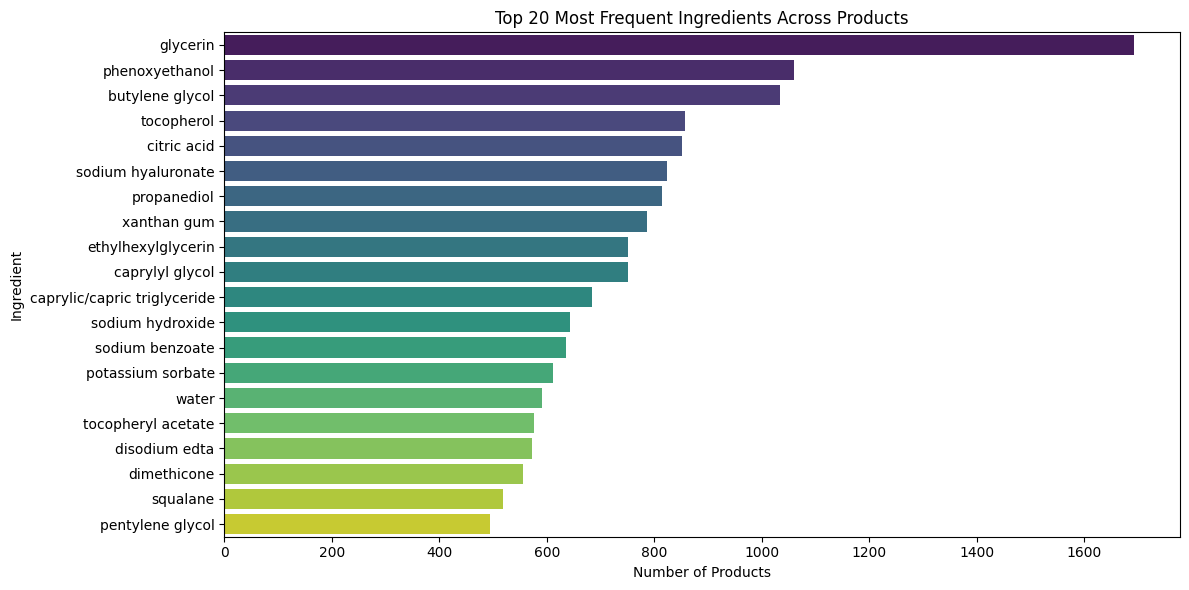

In [3]:
q1 = pd.read_sql("""
    SELECT i.ingredient_name, COUNT(pi.product_id) AS product_count
    FROM ingredients i
    JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
    GROUP BY i.ingredient_name
    ORDER BY product_count DESC
    LIMIT 20;
""", engine)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=q1, x="product_count", y="ingredient_name", hue="ingredient_name", palette="viridis", legend=False)
plt.title("Top 20 Most Frequent Ingredients Across Products")
plt.xlabel("Number of Products")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

## Q2: Ingredients Across Skin Types

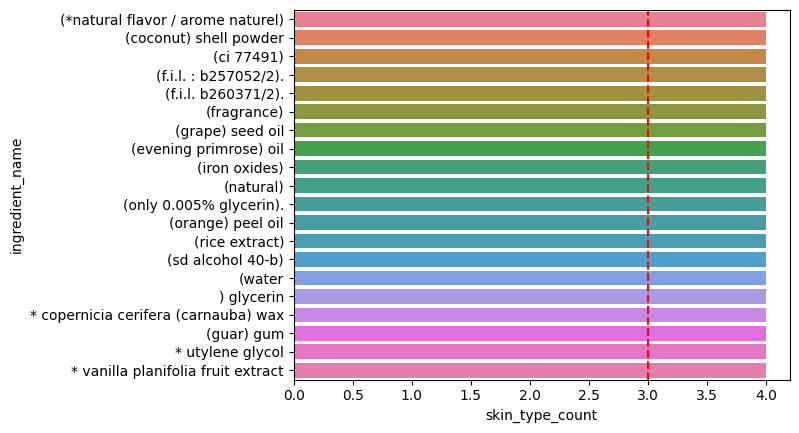

In [4]:
q2 = pd.read_sql("""
    SELECT 
        i.ingredient_name,
        COUNT(DISTINCT pst.skin_type) AS skin_type_count,
        STRING_AGG(DISTINCT pst.skin_type, ', ') AS skin_types
    FROM ingredients i
    JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
    JOIN product_skin_types pst ON pi.product_id = pst.product_id
    GROUP BY i.ingredient_name
    HAVING COUNT(DISTINCT pst.skin_type) >= 3
    ORDER BY skin_type_count DESC
    LIMIT 20;
""", engine)

sns.barplot(data=q2, x="skin_type_count", y="ingredient_name", hue="ingredient_name", legend=False)
plt.axvline(x=3, color="red", linestyle="--")

## Q3: Ingredient Frequency by Category

In [5]:
q3 = pd.read_sql("""
    SELECT 
        p.primary_category,
        i.ingredient_name,
        COUNT(*) AS frequency
    FROM products p
    JOIN product_ingredients pi ON p.product_id = pi.product_id
    JOIN ingredients i ON pi.ingredient_id = i.ingredient_id
    GROUP BY p.primary_category, i.ingredient_name
    ORDER BY p.primary_category, frequency DESC;
""", engine)

# Show top 5 ingredients per category
top_per_category = (
    q3.groupby("primary_category")
    .head(5)
    .reset_index(drop=True)
)
print(top_per_category)

  primary_category  ingredient_name  frequency
0         Skincare         glycerin       1694
1         Skincare   phenoxyethanol       1060
2         Skincare  butylene glycol       1035
3         Skincare       tocopherol        858
4         Skincare      citric acid        852


## Q4: Average Rating by Skin Type

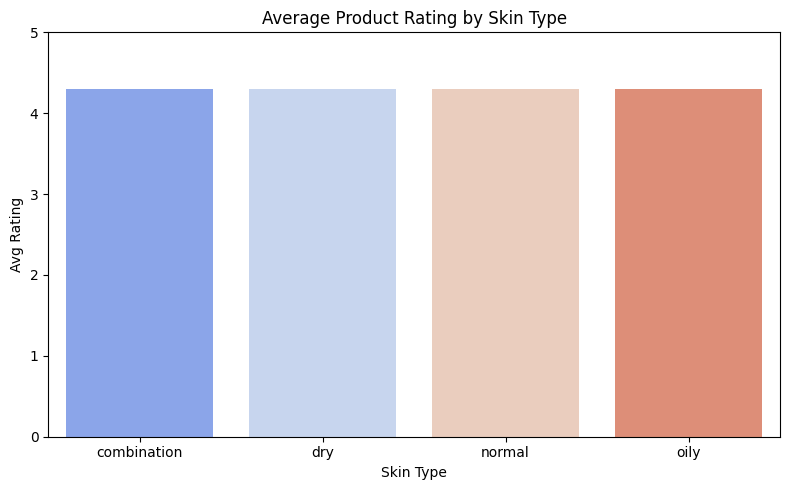

In [6]:
q4 = pd.read_sql("""
    SELECT 
        pst.skin_type,
        ROUND(AVG(r.rating)::numeric, 2) AS avg_rating,
        COUNT(r.review_id) AS review_count
    FROM reviews r
    JOIN product_skin_types pst ON r.product_id = pst.product_id
    GROUP BY pst.skin_type
    ORDER BY avg_rating DESC;
""", engine)

plt.figure(figsize=(8, 5))
sns.barplot(data=q4, x="skin_type", y="avg_rating", hue="skin_type", palette="coolwarm", legend=False)
plt.title("Average Product Rating by Skin Type")
plt.xlabel("Skin Type")
plt.ylabel("Avg Rating")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [8]:
with engine.connect() as conn:
    conn.execute(text("DROP VIEW IF EXISTS ingredient_skin_summary;"))
    conn.execute(text("""
        CREATE VIEW ingredient_skin_summary AS
        SELECT 
            i.ingredient_name,
            p.primary_category,
            pst.skin_type,
            COUNT(DISTINCT p.product_id) AS product_count,
            ROUND(AVG(p.price_usd)::numeric, 2) AS avg_price
        FROM ingredients i
        JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
        JOIN products p ON pi.product_id = p.product_id
        JOIN product_skin_types pst ON p.product_id = pst.product_id
        GROUP BY i.ingredient_name, p.primary_category, pst.skin_type;
    """))
    conn.commit()

print("View created successfully.")
pd.read_sql("SELECT * FROM ingredient_skin_summary LIMIT 10;", engine)

View created successfully.


,ingredient_name,primary_category,skin_type,product_count,avg_price
0,(*natural flavor / arome naturel),Skincare,combination,1,60.0
1,(*natural flavor / arome naturel),Skincare,dry,1,60.0
2,(*natural flavor / arome naturel),Skincare,normal,1,60.0
3,(*natural flavor / arome naturel),Skincare,oily,1,60.0
4,(ci 77491),Skincare,combination,1,26.0
5,(ci 77491),Skincare,dry,1,26.0
6,(ci 77491),Skincare,normal,1,26.0
7,(ci 77491),Skincare,oily,1,26.0
8,(coconut) shell powder,Skincare,combination,2,48.5
9,(coconut) shell powder,Skincare,dry,2,48.5


In [9]:
pd.read_sql("""
    SELECT 
        CASE 
            WHEN price_usd < 20  THEN 'Budget'
            WHEN price_usd < 50  THEN 'Mid-range'
            WHEN price_usd < 100 THEN 'Premium'
            ELSE 'Luxury'
        END AS price_tier,
        COUNT(*) AS product_count,
        ROUND(AVG(rating)::numeric, 2) AS avg_rating
    FROM products p
    JOIN reviews r ON p.product_id = r.product_id
    GROUP BY price_tier
    ORDER BY avg_rating DESC;
""", engine)

,price_tier,product_count,avg_rating
0,Premium,331455,4.33
1,Mid-range,513585,4.30
2,Luxury,64954,4.27
3,Budget,184417,4.26


## Export: Neo4j Edge Data

In [10]:
neo4j_export = pd.read_sql("""
    SELECT 
        i.ingredient_name,
        p.product_id,
        p.product_name,
        p.primary_category
    FROM ingredients i
    JOIN product_ingredients pi ON i.ingredient_id = pi.ingredient_id
    JOIN products p ON pi.product_id = p.product_id;
""", engine)
neo4j_export.to_csv("../data/processed/neo4j_edges.csv", index=False)
print(f"Exported {len(neo4j_export)} rows for Neo4j")
print(neo4j_export.head())

Exported 81486 rows for Neo4j
                    ingredient_name product_id  \
0                      water (aqua)    P504322   
1                dipropylene glycol    P504322   
2  peg-6 caprylic/capric glycerides    P504322   
3                          glycerin    P504322   
4                      2-hexanediol    P504322   

                     product_name primary_category  
0  Gentle Hydra-Gel Face Cleanser         Skincare  
1  Gentle Hydra-Gel Face Cleanser         Skincare  
2  Gentle Hydra-Gel Face Cleanser         Skincare  
3  Gentle Hydra-Gel Face Cleanser         Skincare  
4  Gentle Hydra-Gel Face Cleanser         Skincare  
